In [1]:
import random
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
def generate_connected_dag(n, p):
    tree = nx.DiGraph()
    tree.add_nodes_from(range(n))

    for i in range(1, n):
        parent = random.randint(0, i - 1)
        tree.add_edge(parent, i)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if random.random() < p:
                new_tree = tree.copy()
                new_tree.add_edge(i, j)
                if nx.is_directed_acyclic_graph(new_tree):
                    tree.add_edge(i, j)

    if nx.is_directed_acyclic_graph(tree) and nx.is_weakly_connected(tree):

        mapping = {node: str(node) for node in tree.nodes}
        tree = nx.relabel_nodes(tree, mapping)
        edges_to_remove = []
        for edge in tree.edges:
            edges_to_remove.append(edge)
        for edge in edges_to_remove:
            tree.remove_edge(edge[0], edge[1])
            tree.add_edge(str(edge[0]), str(edge[1]))
        return tree 

In [3]:
def draw_dag(graph, layout_function):
    pos = layout_function(graph)
    nx.draw(graph, pos, with_labels=True, font_weight='bold', node_size=700, node_color='skyblue', arrowsize=20)
    plt.show()

In [4]:
def An(g, source): 
    G_pred = g.pred
    seen = set()
    nextlevel = source
    while nextlevel:
        thislevel = nextlevel
        nextlevel = set()
        for v in thislevel:
            if v not in seen:
                seen.add(v)
                nextlevel.update(G_pred[v])
    return seen

In [5]:
def Pass(e,u,f,v,Re,An_Re): 
    if u not in An_Re: 
        if e == 0 and f == 1:
            return False
        else:
            return True
    elif u in Re:
        if e == 0 and f == 1:
            return True
        else:
            return False
    else:
        return True

In [6]:
def Pass1(e,u,f,v,Re,An_Re): 
    if u not in An_Re: 
        if e == 0 and f == 1:
            return True
        else:
            return True
    elif u in Re:
        if e == 0 and f == 1:
            return True
        else:
            return False
    else:
        return True

In [7]:
def connect(g, source, Re):    
    An_Re = An(g, Re) 
    Q = []
    P = set()
    for ch in set(g.successors(source)):
        Q.append((0,ch))
        P.add((0,ch))
    for pa in set(g.predecessors(source)):
        Q.append((1,pa))
        P.add((1,pa))
    while Q:
        eV = Q.pop(0)
        for ch in set(g.successors(eV[1])):
            if (0,ch) not in P and Pass(eV[0],eV[1],0,ch,Re,An_Re):
                Q.append((0,ch))
                P.add((0,ch))
        for pa in set(g.predecessors(eV[1])):
            if (1,pa) not in P and Pass1(eV[0],eV[1],1,pa,Re,An_Re):
                Q.append((1,pa))
                P.add((1,pa))
    connected = ({item[1] for item in P}-set(Re))|{source}
    return connected

In [8]:
def FCMS(g,u,v):
    mb_v = set([parent for child in g.successors(v) for parent in g.predecessors(child)]) | set(g.successors(v)) | set(g.predecessors(v))
    mb_v.discard(v)
    if u in mb_v:
        return False
    An = nx.subgraph(g, nx.ancestors(g, u) | nx.ancestors(g, v)|{u,v})
    #print("Nodes in An:", list(An.nodes()))
    mb_u = set([parent for child in An.successors(u) for parent in An.predecessors(child)]) | set(An.successors(u)) | set(An.predecessors(u))
    mb_u.discard(u)
    #print("mb_u:",mb_u)
    DC_v = connect(An,v, mb_u)
    #print("DC_v:",DC_v)
    S=set()
    for x in mb_u:
        mb_x=set([parent for child in An.successors(x) for parent in An.predecessors(child)]) | set(An.successors(x)) | set(An.predecessors(x))
        mb_x.discard(x)
        #print("mb_x:",mb_x)
        if mb_x & DC_v!=set():
            S.add(x)
    return S

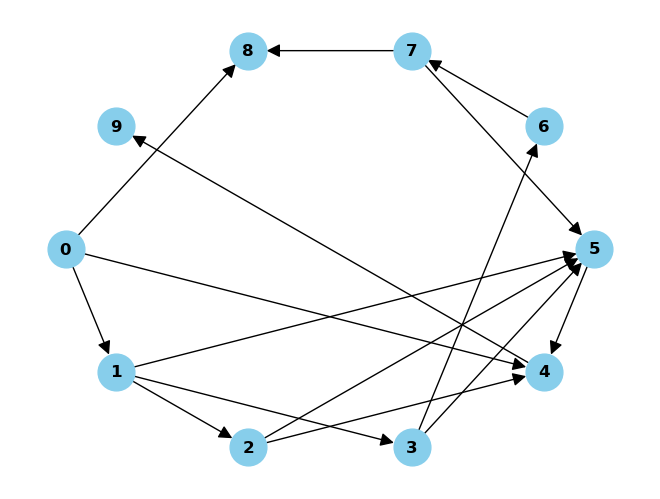

In [9]:
import random
random.seed(10)
G=generate_connected_dag(10, 0.1)
draw_dag(G,nx.shell_layout)

In [10]:
print(G.nodes())


['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [11]:
FCMS(G,'0','8')

False

In [12]:
connect(G, '1', {'7'})

{'0', '1', '2', '3', '4', '5', '6', '8', '9'}

In [1]:
import random
import itertools
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict


import random
import networkx as nx

def generate_random_dag(n: int, l: int, seed: int = None) -> nx.DiGraph:
    if seed is not None:
        random.seed(seed)

    p = min(l / (n - 1), 1.0)      G = nx.DiGraph()
    G.add_nodes_from(range(n))  

    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < p:
                G.add_edge(i, j)

    if not nx.is_directed_acyclic_graph(G):
        return generate_random_dag(n, l, seed=seed + 1)

    return G



def sum_conditioning_sizes_on_graph(G: nx.DiGraph):
    topo = list(nx.topological_sort(G))  
    has_edge = G.has_edge

    sum_parental = 0
    sum_sparse = 0
    pairs_count = 0

    for idx_i in range(len(topo)):
        i = topo[idx_i]
        for idx_j in range(idx_i + 1, len(topo)):
            j = topo[idx_j]

            if has_edge(i, j) or has_edge(j, i):
                continue

            pa_j = set(G.predecessors(j))
            sum_parental += len(pa_j)

            res = FCMS(G,j,i)
            if res is False:
                S = set()
            else:
                S = set(res)
            sum_sparse += len(S)

            pairs_count += 1

    return sum_parental, sum_sparse, pairs_count


def avg_over_trials(n: int, l: int, trials: int = 50, seed0: int = 0):
    """
    """
    total_parental = 0
    total_sparse = 0
    total_pairs = 0
    for t in range(trials):
        G = generate_random_dag(n, l, seed=seed0 + t)
        p_sum, s_sum, cnt = sum_conditioning_sizes_on_graph(G)
        total_parental += p_sum
        total_sparse += s_sum
        total_pairs += cnt

    return (total_parental / trials,
            total_sparse / trials,
            total_pairs / trials)


def run_experiment_and_plot(
    n_list_left=(20, 40, 60, 80, 100),
    l_list=(2, 5, 10, 20),
    n_list_right=(25, 50, 100),
    trials=10,
    seed0=0
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axL, axR = axes

    right_data = {n: {'l': [], 'pct_reduction': []} for n in n_list_right}

    left_data = {l: {'n': [], 'parental': [], 'sparse': []} for l in l_list}

    for l in l_list:
        for n in n_list_left:
            ap, as_, _ = avg_over_trials(n, l, trials=trials, seed0=seed0)
            left_data[l]['n'].append(n)
            left_data[l]['parental'].append(ap)
            left_data[l]['sparse'].append(as_)

        axL.plot(left_data[l]['n'], left_data[l]['sparse'],
                 linestyle='--', marker=None, label=f'sparse, l={l}')
        axL.plot(left_data[l]['n'], left_data[l]['parental'],
                 linestyle='-', marker='o', label=f'parental, l={l}')

    axL.set_xlabel('n (number of nodes)')
    axL.set_ylabel('sum of conditioning set sizes')
    axL.set_title('Model checking: parental vs sparse basis (random DAGs)')
    axL.legend(loc='upper left')

    for n in n_list_right:
        xs = []
        ys = []
        for l in l_list:
            ap, as_, _ = avg_over_trials(n, l, trials=trials, seed0=seed0 + 10_000*(n+l))
            if ap > 0:
                pct = 100.0 * (1.0 - as_ / ap)
            else:
                pct = 0.0
            xs.append(l)
            ys.append(pct)

        right_data[n]['l'] = xs
        right_data[n]['pct_reduction'] = ys
        axR.plot(xs, ys, marker='o', label=f'n={n}')

    axR.set_xlabel('l (expected #neighbors)')
    axR.set_ylabel('% reduction in conditioning set size\n(1 - sparse/parental) × 100')
    axR.set_title('Benefit of sparse basis vs parental basis')
    axR.legend(loc='upper left')

    plt.tight_layout()
    plt.show()





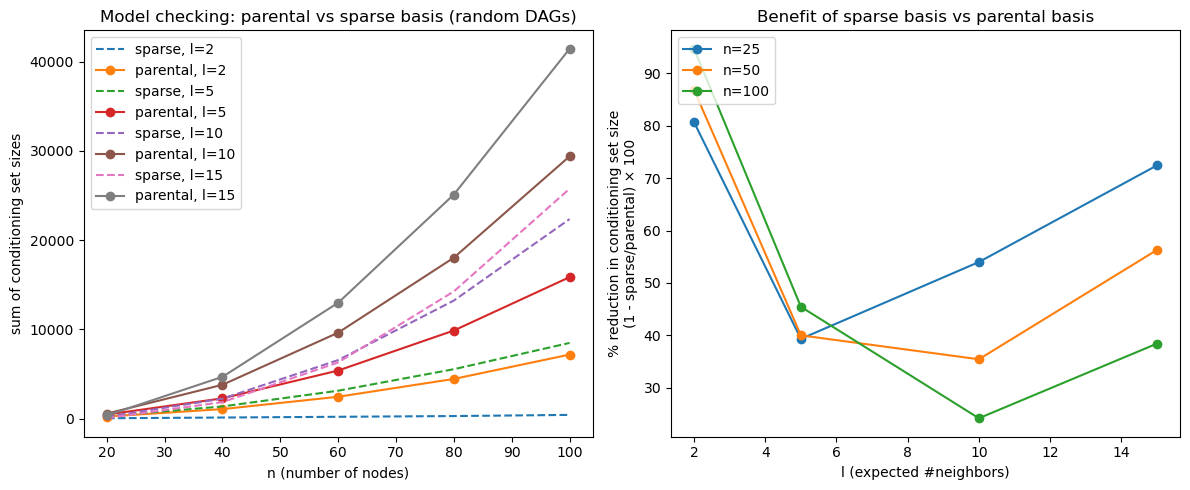

In [19]:
if __name__ == "__main__":
    random.seed(1)

    run_experiment_and_plot(
        n_list_left=(20, 40, 60, 80, 100),
        l_list=(2, 5, 10, 15),
        n_list_right=(25, 50, 100),
        trials=50,
        seed0=42
    )
